<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_05/code_examples/example_07_GaAs_multislice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Week 05 - Example 07: Multislice Simulation of GaAs

This notebook demonstrates a complete multislice simulation for **GaAs**.

We will:
1.  Define the crystal structure and convert the hexagonal unit cell to a larger **rectangular supercell** suitable for FFT-based multislice.
2.  Generate the projected potentials for the slices.
3.  Perform the multislice propagation loop.
4.  Visualize the exit wave and simulate TEM images at different defocus values.

References:
*   Kirkland, E. J. *Advanced Computing in Electron Microscopy*. (Figures 7.9 - 7.12)

## 1. Import Libraries and Parameters

We use `numpy` for calculations and `matplotlib` for display. 

**Simulation Parameters:**
*   Energy: 200 keV ($\lambda \approx 0.0251$ Å)
*   Lattice Constants ($P6_3/m$): $a = 7.606$ Å, $c = 2.909$ Å.
*   Supercell: $5 a_{rect} \times 3 b_{rect}$ based on the rectangular cell definition ($a_{rect}=a$, $b_{rect}=a\sqrt{3}$).
*   Grid: $256 \times 256$ pixels.
*   Pixel Size: $\Delta x \approx 0.15$ Å.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Physical Constants ---
h = 6.62607015e-34    # Planck's constant [J s]
m0 = 9.10938356e-31   # Electron rest mass [kg]
e = 1.602176634e-19   # Elementary charge [C]
c = 2.99792458e8      # Speed of light [m/s]

def get_wavelength_sigma(voltage_kv):
    """
    Calculates the relativistic electron wavelength and the interaction parameter (sigma).
    
    Args:
        voltage_kv (float): Accelerating voltage in kilovolts.
        
    Returns:
        tuple: (wavelength in Angstroms, sigma in SI units [rad / V m])
    """
    V = voltage_kv * 1000
    E0 = m0 * c**2
    
    # Relativistic factors
    # gamma: Lorentz factor, how much mass increases
    gamma = 1 + (e * V) / E0
    beta = np.sqrt(1 - 1/gamma**2)
    
    # Relativistic Wavelength (lambda = h / p)
    lam = h / (np.sqrt(2 * m0 * e * V * (1 + e * V / (2 * E0))))
    
    # Interaction parameter sigma (rad / V m)
    # This defines how much phase shift the electron wave acquires per volt of potential.
    sigma = (2 * np.pi * m0 * e * lam) / (h**2) * gamma
    
    return lam * 1e10, sigma # return wavelength in Angstroms, sigma in SI

voltage = 200.0
lam, sigma_SI = get_wavelength_sigma(voltage)

# Convert sigma to units compatible with Angstroms
# The phase shift is calculation: phi(x) = sigma * Integral( V(x,y,z) dz )
# If V is in Volts and dz is in Angstroms, the product has units [V * A].
# Therefore, we need sigma in units of [rad / (V * A)].
# Since 1 m = 1e10 A, we divide the SI sigma by 1e10.
sigma = sigma_SI / 1e10

print(f"Energy: {voltage} kV")
print(f"Wavelength: {lam:.4f} Å")
print(f"Interaction sigma: {sigma:.4e} rad/(V·Å)")

Energy: 200.0 kV
Wavelength: 0.0251 Å
Interaction sigma: 7.2884e-04 rad/(V·Å)


# --- 2. Structure Generation (GaAs [110]) ---

We need to generate atomic coordinates for the simulation box.
Material: **GaAs** (Zincblende structure, $a = 5.65$ Å).
Orietation: **[110]** (along the beam, $z$).

We will use the **Atomic Simulation Environment (ASE)** to handle the crystallography and coordinate transformations, as manual rotation matrices are prone to errors for this projection.


Unit Cell: 3.997 x 5.653 x 3.997 Å
Simulation Box: 23.98 x 22.61 Å
Slice Thickness (c_repeat): 4.00 Å
Total Atoms: 96


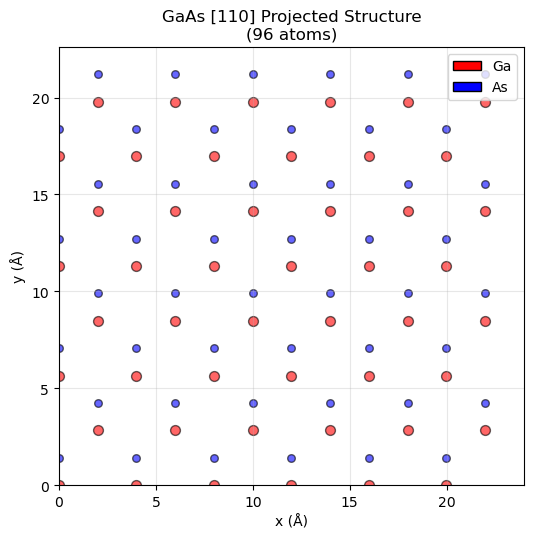

In [6]:
import matplotlib.pyplot as plt

def get_gaas_110_atoms():
    """
    Generates atomic coordinates for GaAs oriented along [110]
    using explicit coordinates from Kirkland Table 7.1.
    """
    # Lattice constant
    a_gaas = 5.6533 
    
    # Unit Cell Dimensions (Kirkland Table 7.1)
    Sx_unit = a_gaas / np.sqrt(2) # a0 = 3.9975
    Sy_unit = a_gaas              # b0 = 5.6533
    thickness_unit = a_gaas / np.sqrt(2) # c0 = 3.9975 (2 layer repeat)

    print(f"Unit Cell: {Sx_unit:.3f} x {Sy_unit:.3f} x {thickness_unit:.3f} Å")
    
    # Base Atoms (Fractional coordinates turned Cartesian)
    # Layer A (z=0)
    # Ga: (0, 0)
    # As: (0.5, 0.75)
    # Layer B (z=c0/2)
    # As: (0, 0.25)
    # Ga: (0.5, 0.5)
    
    base_atoms = [
        ('Ga', 0.0, 0.0, 0.0),
        ('As', 0.5 * Sx_unit, 0.75 * Sy_unit, 0.0),
        ('As', 0.0, 0.25 * Sy_unit, thickness_unit / 2.0),
        ('Ga', 0.5 * Sx_unit, 0.5 * Sy_unit, thickness_unit / 2.0)
    ]
    
    # Tiling (Create Supercell)
    nx_tile = 6
    ny_tile = 4
    
    atoms_list = []
    
    for ix in range(nx_tile):
        for iy in range(ny_tile):
            shift_x = ix * Sx_unit
            shift_y = iy * Sy_unit
            
            for atom in base_atoms:
                elem, ax, ay, az = atom
                atoms_list.append((elem, ax + shift_x, ay + shift_y, az))
                
    Sx_super = Sx_unit * nx_tile
    Sy_super = Sy_unit * ny_tile
        
    return atoms_list, Sx_super, Sy_super, thickness_unit

# Execute generation
supercell_atoms, Sx, Sy, thickness_z = get_gaas_110_atoms()

print(f"Simulation Box: {Sx:.2f} x {Sy:.2f} Å")
print(f"Slice Thickness (c_repeat): {thickness_z:.2f} Å")
print(f"Total Atoms: {len(supercell_atoms)}")

# 5. Visualization (Projected)
plt.figure(figsize=(6, 6))
cols = {'Ga': 'red', 'As': 'blue'}
sizes = {'Ga': 50, 'As': 30}

for atom in supercell_atoms:
    elem, ax, ay, az = atom
    plt.scatter(ax, ay, c=cols[elem], s=sizes[elem], alpha=0.6, edgecolors='black')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', edgecolor='k', label='Ga'),
                   Patch(facecolor='blue', edgecolor='k', label='As')]
plt.legend(handles=legend_elements, loc='upper right')

plt.xlim(0, Sx)
plt.ylim(0, Sy) 
plt.gca().set_aspect('equal')
plt.title(f"GaAs [110] Projected Structure\n({len(supercell_atoms)} atoms)")
plt.xlabel("x (Å)")
plt.ylabel("y (Å)")
plt.grid(True, alpha=0.3)
plt.show()

## 3. Generate Projected Potentials

We discretize the projected potential $V_p(x,y)$ for the slice. The slice thickness is $c_{hex} = 2.909$ Å.
We use a simple Lorentzian or Gaussian parameterization for the atomic potentials for this example.

Slice 1 atoms: 48
Slice 2 atoms: 48
Calculating potentials...


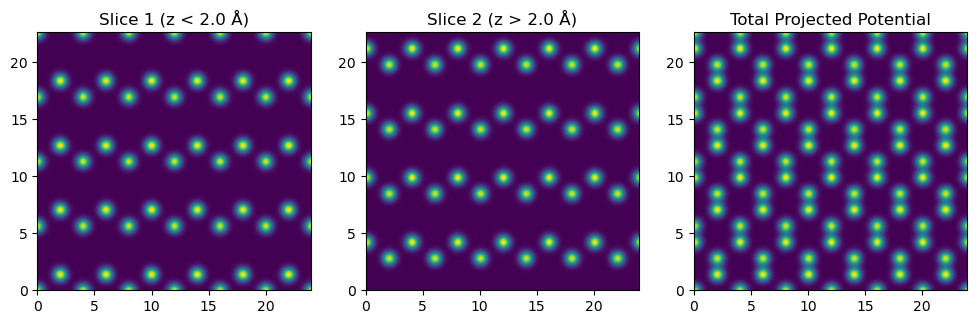

In [7]:
# --- Grid Setup ---
nx, ny = 256, 256
x = np.linspace(0, Sx, nx, endpoint=False)
y = np.linspace(0, Sy, ny, endpoint=False)
X, Y = np.meshgrid(x, y)

def calculate_projected_potential(atoms, Sx, Sy, nx, ny):
    """
    Calculate projected potential map V_proj(x,y).
    Uses Gaussian approximation for atomic scattering potentials.
    """
    V = np.zeros((ny, nx))
    
    # Parameters for atomic potentials (Simplified Gaussian Model)
    # Z numbers: Ga=31, As=33. They are very similar!
    # Contrast will be weak between them unless very high resolution.
    scale_Ga = 31.0 * 2.0 
    scale_As = 33.0 * 2.0
    width = 0.4 # Angstroms
    w2 = 2 * width**2

    for atom in atoms:
        elem, ax, ay, az = atom
        
        strength = scale_Ga if elem == 'Ga' else scale_As
        
        # Periodic Boundary Distances
        # We need to consider atoms wrapping around edges.
        # Simple loop over 3x3 neighbors for boundary atoms (brute force but robust)
        for dx_shift in [-Sx, 0, Sx]:
            for dy_shift in [-Sy, 0, Sy]:
                
                # Atom position shifted
                ax_s = ax + dx_shift
                ay_s = ay + dy_shift
                
                # Distance grid
                dx = X - ax_s
                dy = Y - ay_s
                R2 = dx**2 + dy**2
                
                # Mask for speed
                mask = R2 < (2.0**2)
                if np.any(mask):
                    V[mask] += strength * np.exp(-R2[mask] / w2)
        
    return V

# --- Slicing Strategy ---
# The repeat distance thickness_z is ~4.0 A.
# For multislice, slices should be thin (< 2 A usually).
# We will split the unit cell into 2 slices.
# Slice 1: z < thickness_z / 2
# Slice 2: z >= thickness_z / 2

slice_limit = thickness_z / 2.0
atoms_layer1 = [a for a in supercell_atoms if a[3] < slice_limit]
atoms_layer2 = [a for a in supercell_atoms if a[3] >= slice_limit]

print(f"Slice 1 atoms: {len(atoms_layer1)}")
print(f"Slice 2 atoms: {len(atoms_layer2)}")

# Calculate Potentials
print("Calculating potentials...")
V1 = calculate_projected_potential(atoms_layer1, Sx, Sy, nx, ny)
V2 = calculate_projected_potential(atoms_layer2, Sx, Sy, nx, ny)

V_full = V1 + V2

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(V1, cmap='viridis', extent=[0, Sx, 0, Sy])
plt.title(f'Slice 1 (z < {slice_limit:.1f} Å)')
plt.subplot(1, 3, 2)
plt.imshow(V2, cmap='viridis', extent=[0, Sx, 0, Sy])
plt.title(f'Slice 2 (z > {slice_limit:.1f} Å)')
plt.subplot(1, 3, 3)
plt.imshow(V_full, cmap='viridis', extent=[0, Sx, 0, Sy])
plt.title('Total Projected Potential')
plt.show()

## 4. Multislice Propagation Loop

Propagate the electron wave through the specimen.
*   Initial state: Plane wave.
*   Loop: For each slice layer (1 and 2), apply Transmission ($e^{i \sigma V}$) and Propagation ($P(k)$).
*   Total thickness: $\sim 50$ Å ($\sim 17$ unit cells).

Simulating 25 unit cells (99.94 Å)...
Simulation complete.


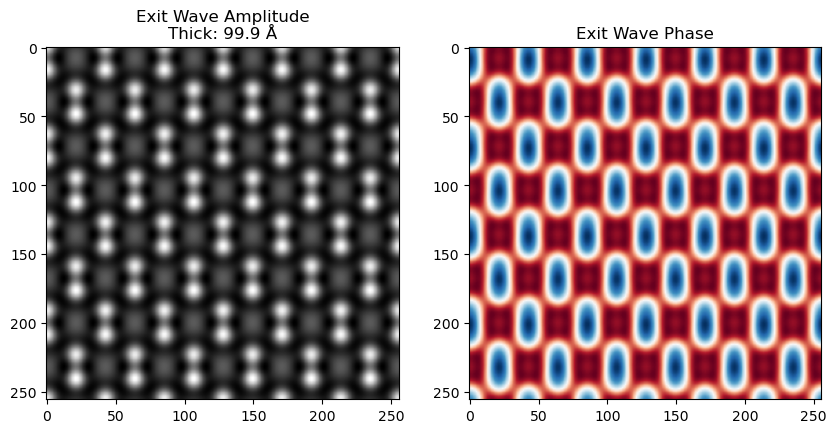

In [8]:
# --- 3. Fresnel Propagation ---

# Frequency Grid
kx = np.fft.fftfreq(nx, d=Sx/nx)
ky = np.fft.fftfreq(ny, d=Sy/ny)
KX_freq, KY_freq = np.meshgrid(kx, ky)
K2 = KX_freq**2 + KY_freq**2

# Propagator P(k)
# dz is half the unit cell thickness
dz_slice = thickness_z / 2.0
P = np.exp(-1j * np.pi * lam * dz_slice * K2)

# Transmission Functions T(r)
T1 = np.exp(1j * sigma * V1)
T2 = np.exp(1j * sigma * V2)

# Initialization
psi = np.ones((ny, nx), dtype=complex)

# Multislice Loop
# We want to simulate a tangible thickness, e.g. 10 nm = 100 Å.
# Unit cell thickness ~ 4 Å. So ~25 unit cells.
num_unit_cells = 25
total_thickness = num_unit_cells * thickness_z
print(f"Simulating {num_unit_cells} unit cells ({total_thickness:.2f} Å)...")

for i in range(num_unit_cells):
    # Slice 1
    Psi_k = np.fft.fft2(psi) 
    Psi_k *= P 
    psi = np.fft.ifft2(Psi_k)
    psi *= T1
    
    # Slice 2
    Psi_k = np.fft.fft2(psi)
    Psi_k *= P
    psi = np.fft.ifft2(Psi_k)
    psi *= T2

exit_wave = psi
print("Simulation complete.")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(np.abs(exit_wave), cmap='gray')
plt.title(f"Exit Wave Amplitude\nThick: {total_thickness:.1f} Å")
plt.subplot(1, 2, 2)
plt.imshow(np.angle(exit_wave), cmap='RdBu')
plt.title("Exit Wave Phase")
plt.show()

## 5. Simulate Defocus Series

Apply the Contrast Transfer Function (CTF) to the exit wave to simulate images at Scherzer defocus and other values.
Requires spherical aberration $C_s \approx 1.0$ mm (typical).

Scherzer Defocus: -600.95 Å


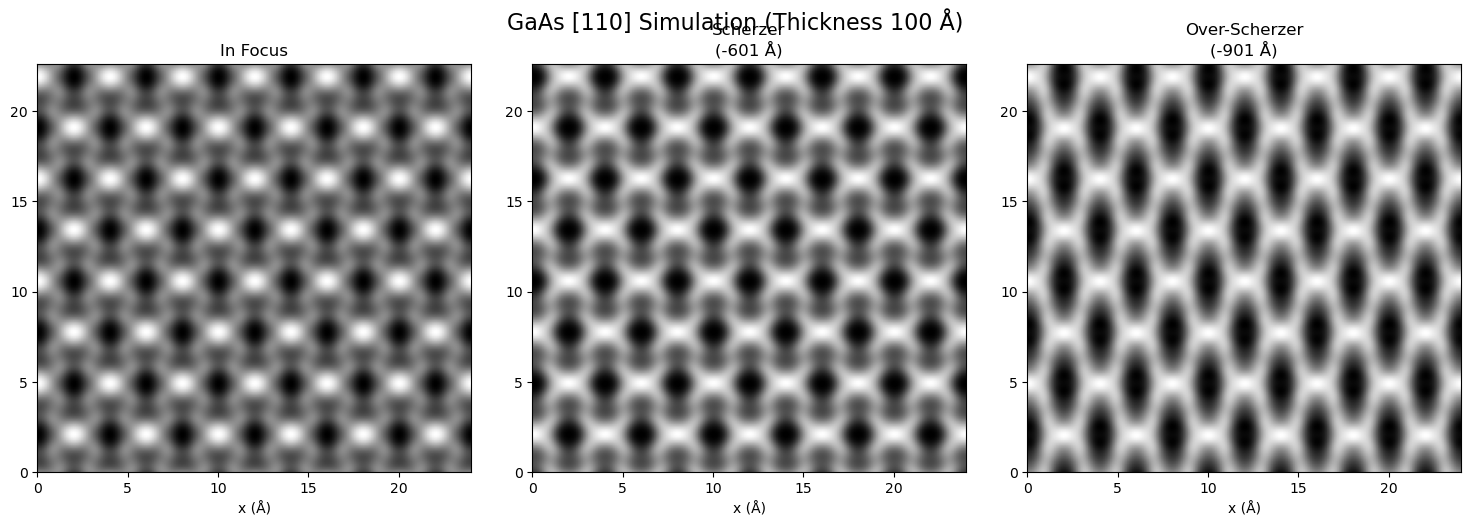

In [9]:
# --- 4. Image Formation (CTF) ---

# Microscope Parameters
Cs_mm = 1.0 
Cs = Cs_mm * 1e7
df_scherzer = -1.2 * np.sqrt(Cs * lam)
print(f"Scherzer Defocus: {df_scherzer:.2f} Å")

defocus_list = [0, df_scherzer, 1.5*df_scherzer]
labels = ["In Focus", f"Scherzer\n({df_scherzer:.0f} Å)", f"Over-Scherzer\n({1.5*df_scherzer:.0f} Å)"]

plt.figure(figsize=(15, 5))

for i, df in enumerate(defocus_list):
    # Setup CTF
    # chi = pi*lambda*k^2*df + 0.5*pi*Cs*lambda^3*k^4
    chi = np.pi * lam * K2 * df + (np.pi / 2.0) * Cs * (lam**3) * (K2**2)
    
    # Pupil Function
    # Include aperture? Let's assume aperture is large enough to pass 'dumbbells'
    # GaAs [110] dumbbell spacing is ~1.4 A.
    # Resolution limit at Scherzer ~ 2.5 A (for 200kV, Cs=1.0mm).
    # We might NOT resolve the dumbbells with these generic parameters!
    # Let's see.
    Pupil = np.exp(-1j * chi)
    
    Image_k = np.fft.fft2(exit_wave) * Pupil
    Image_wave = np.fft.ifft2(Image_k)
    Intensity = np.abs(Image_wave)**2
    
    plt.subplot(1, 3, i+1)
    plt.imshow(Intensity, cmap='gray', extent=[0, Sx, 0, Sy])
    plt.title(labels[i])
    plt.xlabel('x (Å)')

plt.suptitle(f"GaAs [110] Simulation (Thickness {total_thickness:.0f} Å)", fontsize=16)
plt.tight_layout()
plt.show()